# Sector Allocation with Group Constraints

This notebook shows how to enforce **sector-level allocation limits** using
`Constraints.group_constraints`. We define a five-asset universe split into
an Equity bucket (assets 0-1) and a Fixed-Income bucket (assets 2-4), then
trace the variance-efficient frontier subject to those bounds.

In [1]:
import numpy as np
import pandas as pd
from pyvallocation import PortfolioWrapper, Constraints

## Define expected returns and covariance

Five assets with decreasing expected returns and heterogeneous volatilities.

In [2]:
assets = ["US_Equity", "EU_Equity", "IG_Credit", "Govt_Bonds", "TIPS"]

mu = np.array([0.10, 0.08, 0.06, 0.04, 0.03])

cov = np.eye(5) * 0.03 + 0.01
np.fill_diagonal(cov, [0.05, 0.04, 0.03, 0.025, 0.02])

print("Expected returns:", mu)
print("\nCovariance matrix:\n", cov.round(4))

Expected returns: [0.1  0.08 0.06 0.04 0.03]

Covariance matrix:
 [[0.05  0.01  0.01  0.01  0.01 ]
 [0.01  0.04  0.01  0.01  0.01 ]
 [0.01  0.01  0.03  0.01  0.01 ]
 [0.01  0.01  0.01  0.025 0.01 ]
 [0.01  0.01  0.01  0.01  0.02 ]]


## Set up group constraints

- **Equity** (assets 0-1): between 30% and 60%
- **Fixed Income** (assets 2-4): between 30% and 70%
- Each individual asset must stay between 5% and 40%.

In [3]:
constraints = Constraints(
    group_constraints={
        "Equity": ([0, 1], 0.30, 0.60),
        "Fixed Income": ([2, 3, 4], 0.30, 0.70),
    },
    bounds=(0.05, 0.40),
)

print(constraints)

Constraints(long_only=True, total_weight=1.0, bounds=(0.05, 0.4), relative_bounds=None, group_constraints={'Equity': ([0, 1], 0.3, 0.6), 'Fixed Income': ([2, 3, 4], 0.3, 0.7)}, additional_G_h=None, additional_A_b=None)


## Compute the variance-efficient frontier

In [4]:
wrapper = PortfolioWrapper.from_moments(mu, cov, constraints=constraints)
frontier = wrapper.variance_frontier(num_portfolios=8)

## Inspect frontier weights: equity vs fixed-income split

In [5]:
print("=== Sector-Constrained Frontier ===\n")
for i in range(frontier.weights.shape[1]):
    w = frontier.weights[:, i]
    eq = w[0] + w[1]
    fi = w[2] + w[3] + w[4]
    print(
        f"P{i}: Equity={eq:.1%}  FI={fi:.1%}  "
        f"Return={frontier.returns[i]:.2%}  "
        f"Vol={frontier.risks[i]:.2%}"
    )

=== Sector-Constrained Frontier ===

P0: Equity=30.0%  FI=70.0%  Return=5.46%  Vol=11.75%
P1: Equity=32.9%  FI=67.1%  Return=5.78%  Vol=11.85%
P2: Equity=38.0%  FI=62.0%  Return=6.11%  Vol=12.02%
P3: Equity=43.0%  FI=57.0%  Return=6.44%  Vol=12.25%
P4: Equity=48.1%  FI=51.9%  Return=6.77%  Vol=12.54%
P5: Equity=53.2%  FI=46.8%  Return=7.09%  Vol=12.88%
P6: Equity=58.9%  FI=41.1%  Return=7.42%  Vol=13.27%
P7: Equity=60.0%  FI=40.0%  Return=7.75%  Vol=13.95%


## Visualise sector allocations across the frontier

The stacked bar chart shows how the optimizer trades off equity and
fixed-income exposure as it moves from low-risk to high-return portfolios.

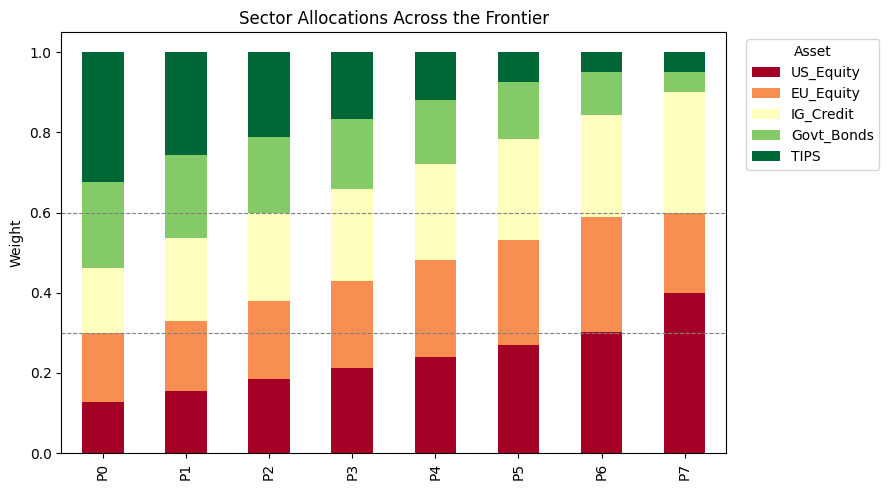

In [6]:
import matplotlib.pyplot as plt

n_port = frontier.weights.shape[1]
weight_df = pd.DataFrame(
    frontier.weights.T, columns=assets,
    index=[f"P{i}" for i in range(n_port)],
)

fig, ax = plt.subplots(figsize=(9, 5))
weight_df.plot.bar(stacked=True, ax=ax, colormap="RdYlGn")
ax.set_ylabel("Weight")
ax.set_title("Sector Allocations Across the Frontier")
ax.legend(title="Asset", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.axhline(0.30, ls="--", color="grey", lw=0.8, label="Equity min (30%)")
ax.axhline(0.60, ls="--", color="grey", lw=0.8, label="Equity max (60%)")
fig.tight_layout()
plt.show()